In [1]:
import numpy as np
import pandas as pd
import sys, os

In [2]:
path = "../data/mi-experiment/gel-goodddd"
eeg, marker = os.listdir(path)

Zeitpunkt abstimmen - vor markers datastep alles abschneiden

Problem:
- Marker-Stream hat 433919.2829826 als erstes Timestamp
- In EEG-Stream kommt 433919.263455 bzw 433919.2930798 am naechsten ran

In [3]:
df_eeg = pd.read_csv(f"{path}/{eeg}", header=None)
df_marker = pd.read_csv(f"{path}/{marker}", header=None)

# EEG Werte VOR Beginn des Experiments abschneiden
exp_start = df_marker.iloc[0,0]
print("[marker.csv] Start des Experiments: ", exp_start)

idx = df_eeg[df_eeg.iloc[:, 0] > exp_start].first_valid_index()
print("[eeg.csv] Start des Experiments am Index: ", idx)

#df_eeg = df_eeg.drop(df_eeg.index[0:idx,])
df_eeg = df_eeg[idx:] # alte index struktur wird beibehalten
df_eeg = df_eeg.reset_index(drop=True)
print(df_eeg)



[marker.csv] Start des Experiments:  433919.2829826
[eeg.csv] Start des Experiments am Index:  348
                   0                                                  1
0      433919.293080  [187546.34375, 134541.0625, 131614.5, 144903.9...
1      433919.298014  [186083.734375, 134512.984375, 131616.28125, 1...
2      433919.326063  [184902.9375, 134514.859375, 131617.8125, 1449...
3      433919.326074  [185438.03125, 134533.09375, 131609.9375, 1448...
4      433919.327977  [186954.921875, 134556.078125, 131607.875, 144...
...              ...                                                ...
27539  434029.721045  [189014.046875, 133014.609375, 128734.703125, ...
27540  434029.721047  [188075.09375, 133003.25, 128741.40625, 137741...
27541  434029.721050  [188311.046875, 133004.859375, 128731.2109375,...
27542  434029.726898  [188642.828125, 133016.84375, 128724.6875, 137...
27543  434029.726903  [189374.8125, 133034.8125, 128718.609375, 1377...

[27544 rows x 2 columns]


TODO: MI RECHTS in rechts_array, MI LINKS in links_array speichern

In [4]:
print("Positionen der MI-LINKS / MI-RECHTS in marker.csv: ")
# Links: [ [idx-start-1, idx-end-1], [idx-start-2, idx-end-2], ...]
i_left_start = np.array((df_marker.index[df_marker.iloc[:,1] == "['LINKS']"]))
idx_left = np.append(i_left_start, i_left_start+2)
idx_left = np.sort(idx_left)
idx_left = idx_left.reshape((int(idx_left.shape[0]/2), 2))
print("links: ", idx_left)

# Rechts
i_rechts_start = np.array((df_marker.index[df_marker.iloc[:,1] == "['RECHTS']"]))
idx_rechts = np.append(i_rechts_start, i_rechts_start+2)
idx_rechts = np.sort(idx_rechts)
idx_rechts = idx_rechts.reshape((int(idx_rechts.shape[0]/2), 2))
print("rechts: ", idx_rechts)



Positionen der MI-LINKS / MI-RECHTS in marker.csv: 
links:  [[ 1  3]
 [ 5  7]
 [ 9 11]
 [17 19]
 [37 39]]
rechts:  [[13 15]
 [21 23]
 [25 27]
 [29 31]
 [33 35]]


In [5]:
# Mache es irgendwie, dann mache es schoen

# Links: [ [ts-start-1, ts-end-1], [ts-start-2, ts-end-2], ...]
ts_left = []
for i in range(len(idx_left)):
    #print(df_marker.iloc[idx_left[i,:], 0])
    ts_left.append([df_marker.iloc[idx_left[i,:], 0]])
#print(ts_left)

ts_right = []
for i in range(len(idx_rechts)):
    #print(df_marker.iloc[idx_left[i,:], 0])
    ts_right.append([df_marker.iloc[idx_rechts[i,:], 0]])
print(ts_right)

#ts_left = df_marker.iloc[idx_left[i,1], 0] - wie waere das richtig????


[[13    433953.687545
15    433960.956835
Name: 0, dtype: float64], [21    433975.27083
23    433982.54007
Name: 0, dtype: float64], [25    433986.083945
27    433993.347024
Name: 0, dtype: float64], [29    433996.872214
31    434004.141507
Name: 0, dtype: float64], [33    434007.697311
35    434014.966492
Name: 0, dtype: float64]]


TODO: aus ```eeg.csv``` die Epochs rausschneiden

In [23]:

import ast 
indizes = pd.Index(df_eeg.iloc[:,0])

# idx = indizes.get_indexer - nimmt DIE NEUE Index Struktur
# (als ob EEG von 300 beginnt)

# pandas Series:
#  –  besteht immer aus 2 Teilen - den Werten und dem dazugehörigen Index.


# Links
left_class = []
ts_left_np = np.array(ts_left)
for i in range(len(ts_left_np)):
    idx = indizes.get_indexer(ts_left_np[i,:].flatten(), method="nearest")
    epochs_left = df_eeg.iloc[idx,0]
    el = epochs_left.index.tolist()
    left_class.append((df_eeg.iloc[el[0]:el[1],1]).tolist())

left_class = list(map(lambda el: ast.literal_eval(el),(left_class[0])))

# Rechts
right_class = []
ts_right_np = np.array(ts_right)
for i in range(len(ts_left_np)):
    idx = indizes.get_indexer(ts_right_np[i,:].flatten(), method="nearest")
    epochs_right = df_eeg.iloc[idx,0]
    i = epochs_right.index.tolist()
    right_class.append((df_eeg.iloc[i[0]:i[1],1]).tolist())

right_class = list(map(lambda el: ast.literal_eval(el),(right_class[0])))



Die EEG Werte liegen in ```right_class``` bzw ```left_class``` Arrays vor

- nur EEG Kanaele lassen (ch1-ch8)
- Notch Filter anwenden
- Bandpassfilter anwenden


In [47]:
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.fft

<Figure size 640x480 with 0 Axes>

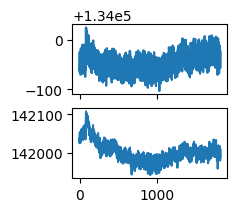

In [113]:
# nur 8 EEG Kanaele (konnte btw schon viel frueher gemacht werden)

# MI: Rechts, C3 Elektrode, Ch2 (index: 1)
#     Links, C4 Elektrode, Ch4 (index: 3)
right = np.array(right_class)[:,0:8]
c3 = right[:,1]
c4 = right[:,3]
fig = plt.figure()
fig, ax = plt.subplots(figsize=(2,2),
                       nrows = 2, sharex= "all")
ax[0].plot(c3) # <------ Channel definieren
ax[1].plot(c4) 
# !!! # plot C3 using x-Aches as index array 0..N-1

<Figure size 640x480 with 0 Axes>

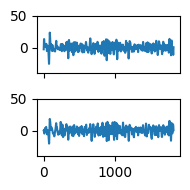

In [121]:
#Bandpass
# 1. DC-Offset vorab entfernen (Demaining)
c3_centered = c3 - c3.mean()
c4_centered = c4 - c4.mean()
b,a = signal.butter (2, [3, 20], fs = 250, btype = "band")

c3_band = signal.filtfilt (b,a, c3_centered) # <------ Channel definieren
c4_band = signal.filtfilt (b,a, c4_centered) # <------ Channel definieren

fig = plt.figure()
fig, ax = plt.subplots(figsize=(2,2),
                       nrows = 2, sharex= True)
ax[0].plot(c3_band) # <------ Channel definieren
ax[0].set_ylim(-40,50)
ax[1].plot(c4_band) 
ax[1].set_ylim(-40,50)
plt.tight_layout()


# !!! # plot C3 using x-Aches as index array 0..N-1


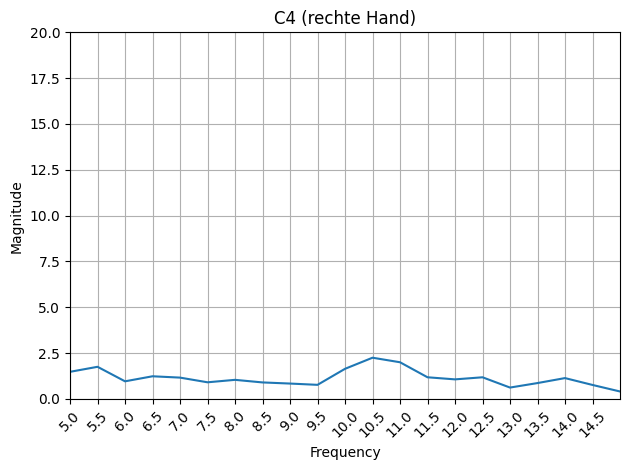

In [126]:
from scipy.fft import fft
import cmath #fuer komplexe zahlen

# ---------------------- SPEKTRUM VISUALISIEREN
# WINDOW SIZE: 500 Samples = 2 sec => 0.5Hz Unterschied erkennen
# input: df_bandfiltered (ES IST SCHON EEG 8.CHANNEL!)
windows_size = 500
n_windows = len(c4_band) // windows_size
df_truncated = c4_band[:n_windows*windows_size]

fft_average = np.zeros(shape=(windows_size,),
                            dtype="float64") #complex128
# WICHTIG: "apply a Hanning Window"
hann_window = signal.windows.hann(500)

for w in range(n_windows):
    #nimm w.te windows_size Datenpunkte
    window = df_truncated[w*windows_size : (w*windows_size + windows_size)]
    filtered_window = window * hann_window
    freq = np.fft.fft(filtered_window)

# magnitude: r = wurzel(real^2 + imaginaer^2)
# ODER abs(number, /)
# Return the absolute value of a number. ... If the argument is a complex number,
# its magnitude is returned.
    freq_squared = np.abs(freq) # magnitude 
    fft_average += freq_squared

fft_average = fft_average / windows_size # durchscnitt

frequencies = np.fft.fftfreq(500, 1/250)

# Keep only positive frequencies
positive_frequencies = frequencies[frequencies > 0]
#print(positive_frequencies)
positive_fft_values = fft_average[frequencies > 0]

# Plot
plt.plot(positive_frequencies, positive_fft_values)
plt.grid(visible=True)
plt.title("C4 (rechte Hand)")
plt.xticks(np.arange(5, 15, 0.5), rotation=45)  # von 5 bis 30, Schrittweite 1
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.xlim(5,15)
plt.ylim(0,20)
plt.tight_layout()
plt.show()
# To get power, you square the magnitude. Power spectral density (PSD) plots show 
# power (magnitude squared) on the y-axis and frequency on the x-axis